In [1]:
import sys
sys.path.append('..')

from SmoothSurface import SmoothSurface
from fresnel import transmissivity, refraction_angle, fresnel_coefficients
import numpy as np
import matplotlib.pyplot as plt

In [35]:
epsilon_r = 20
s = SmoothSurface(epsilon_r)
theta_i = 10
theta_t = s.refraction_angle(theta_i)
T1 = s.M_coh_T(theta_i, True)
T2 = s.M_coh_T(theta_t, False)
T1 * T2


array([[0.36350993, 0.        , 0.        , 0.        ],
       [0.        , 0.35032706, 0.        , 0.        ],
       [0.        , 0.        , 0.35685763, 0.        ],
       [0.        , 0.        , 0.        , 0.35685763]])

In [36]:
transmissivity(theta_i, epsilon_r)[0]**2

0.3635099295280813

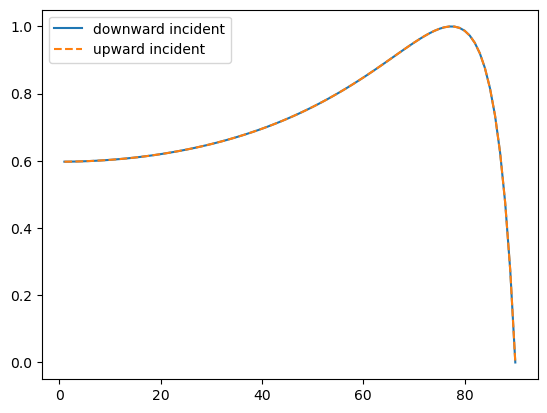

In [29]:
epsilon_r = 20
theta_is = np.linspace(1, 90, 90)
s = SmoothSurface(epsilon_r)
Num = len(theta_is)
ri = np.zeros(Num)
rt = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_t = refraction_angle(theta_i, epsilon_r)
    # rv1,x,_,_ = fresnel_coefficients(theta_i, epsilon_r)
    # rv2,y,_,_ = fresnel_coefficients(theta_t, 1/epsilon_r)
    x,_ = transmissivity(theta_i, epsilon_r)
    # T = s.M_coh_T(theta_i, True)
    T = s.M_coh_T(theta_t, False)
    y = T[0,0]*epsilon_r
    # _,y = transmissivity(theta_t, 1/epsilon_r)
    ri[i] = x
    rt[i] = y

plt.figure()
plt.plot(theta_is, ri, label='downward incident')
plt.plot(theta_is, rt, '--', label='upward incident')
plt.legend()
plt.show()

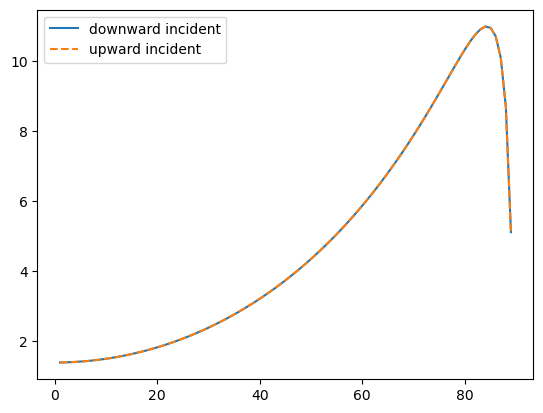

In [3]:
epsilon_r = 100
theta_is = np.linspace(1, 89, 90)
s = SmoothSurface(epsilon_r)
Num = len(theta_is)
ri = np.zeros(Num)
rt = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    theta_t = refraction_angle(theta_i, epsilon_r)
    T = s.M_coh_T(theta_i, True)
    x = T[0,0]
    y = T[1, 1]
    T = s.M_coh_T(theta_t, False)
    x = x * T[0, 0]
    y = y * T[1, 1]
    ri[i]=x
    # rt[i] = y
    x,y = transmissivity(theta_i, epsilon_r)
    # ri[i] = x**2
    rt[i] = x**2
ri = 10*np.log10(4*np.pi*ri)
rt = 10*np.log10(4*np.pi*rt)
plt.figure()
plt.plot(theta_is, ri, label='downward incident')
plt.plot(theta_is, rt, '--', label='upward incident')
plt.legend()
plt.show()